# 1. Carga e Padronização dos Dados

In [217]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import re
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

In [218]:
# Carregamento do arquivo
arquivo = '../data/raw/base-de-dados.xlsx'

In [219]:
# Carregamento dos dados
df22 = pd.read_excel(arquivo, sheet_name='PEDE2022')
df23 = pd.read_excel(arquivo, sheet_name='PEDE2023')
df24 = pd.read_excel(arquivo, sheet_name='PEDE2024')

print(f"2022: {df22.shape} | 2023: {df23.shape} | 2024: {df24.shape}")

2022: (860, 42) | 2023: (1014, 48) | 2024: (1156, 50)


In [ ]:
# Padronização das colunas

def padronizar(df, ano):
    renames = {
        2022: {
            'RA': 'RA', 'Fase': 'FASE', 'Turma': 'TURMA',
            'Nome': 'NOME', 'Gênero': 'GENERO',
            'Ano ingresso': 'ANO_INGRESSO',
            'Instituição de ensino': 'INSTITUICAO',
            'INDE 22': 'INDE', 'IAA': 'IAA', 'IEG': 'IEG',
            'IPS': 'IPS', 'IDA': 'IDA', 'IPP': 'IPP',
            'IPV': 'IPV', 'IAN': 'IAN',
            'Pedra 22': 'PEDRA',
            'Defas': 'DEFASAGEM',
            'Fase ideal': 'FASE_IDEAL',
            'Atingiu PV': 'PONTO_VIRADA',
            'Indicado': 'INDICADO_BOLSA',
            'Matem': 'NOTA_MAT', 'Portug': 'NOTA_PORT', 'Inglês': 'NOTA_ING',
        },
        2023: {
            'RA': 'RA', 'Fase': 'FASE', 'Turma': 'TURMA',
            'Nome Anonimizado': 'NOME', 'Gênero': 'GENERO',
            'Ano ingresso': 'ANO_INGRESSO',
            'Instituição de ensino': 'INSTITUICAO',
            'INDE 2023': 'INDE',
            'IAA': 'IAA', 'IEG': 'IEG', 'IPS': 'IPS',
            'IDA': 'IDA', 'IPP': 'IPP', 'IPV': 'IPV', 'IAN': 'IAN',
            'Pedra 2023': 'PEDRA',
            'Defasagem': 'DEFASAGEM', 'Fase Ideal': 'FASE_IDEAL',
            'Atingiu PV': 'PONTO_VIRADA',
            'Indicado': 'INDICADO_BOLSA',
            'Mat': 'NOTA_MAT', 'Por': 'NOTA_PORT', 'Ing': 'NOTA_ING',
        },
        2024: {
            'RA': 'RA', 'Fase': 'FASE', 'Turma': 'TURMA',
            'Nome Anonimizado': 'NOME', 'Gênero': 'GENERO',
            'Ano ingresso': 'ANO_INGRESSO',
            'Instituição de ensino': 'INSTITUICAO',
            'INDE 2024': 'INDE',
            'IAA': 'IAA', 'IEG': 'IEG', 'IPS': 'IPS',
            'IDA': 'IDA', 'IPP': 'IPP', 'IPV': 'IPV', 'IAN': 'IAN',
            'Pedra 2024': 'PEDRA',
            'Defasagem': 'DEFASAGEM', 'Fase Ideal': 'FASE_IDEAL',
            'Atingiu PV': 'PONTO_VIRADA',
            'Indicado': 'INDICADO_BOLSA',
            'Mat': 'NOTA_MAT', 'Por': 'NOTA_PORT', 'Ing': 'NOTA_ING',
            'Ativo/ Inativo': 'STATUS',
        }
    }

    df = df.rename(columns=renames[ano])
    df['ANO'] = ano

    colunas_base = ['RA', 'FASE', 'ANO', 'INDE', 'IAA', 'IEG', 'IPS',
                    'IDA', 'IPV', 'IAN', 'PEDRA', 'DEFASAGEM', 'PONTO_VIRADA']

    # IPP não existe em 2022 — criar com NaN
    if 'IPP' not in df.columns:
        df['IPP'] = np.nan

    cols = [c for c in colunas_base + ['IPP', 'GENERO', 'INSTITUICAO',
            'ANO_INGRESSO', 'NOTA_MAT', 'NOTA_PORT', 'NOTA_ING',
            'INDICADO_BOLSA', 'FASE_IDEAL'] if c in df.columns]

    return df[cols].copy()


df22_std = padronizar(df22, 2022)
df23_std = padronizar(df23, 2023)
df24_std = padronizar(df24, 2024)

print(df22_std.shape, df23_std.shape, df24_std.shape)

(860, 22) (1014, 22) (1156, 22)


In [221]:
# Consolidando em um único dataset
df = pd.concat([df22_std, df23_std, df24_std], ignore_index=True)

print(f"Total consolidados: {df.shape}")
print(f"Anos: {df['ANO'].value_counts().sort_index().to_dict()}")

df.head()

Total consolidados: (3030, 22)
Anos: {2022: 860, 2023: 1014, 2024: 1156}


,RA,FASE,ANO,INDE,IAA,IEG,IPS,IDA,IPV,IAN,PEDRA,DEFASAGEM,PONTO_VIRADA,IPP,GENERO,INSTITUICAO,ANO_INGRESSO,NOTA_MAT,NOTA_PORT,NOTA_ING,INDICADO_BOLSA,FASE_IDEAL
0,RA-1,7,2022,5.783,8.300,4.100,5.600,4.000,7.278,5.000,Quartzo,-1,Não,NaN,Menina,Escola Pública,2016,2.700,3.500,6.000,Sim,Fase 8 (Universitários)
1,RA-2,7,2022,7.055,8.800,5.200,6.300,6.800,6.778,10.000,Ametista,0,Não,NaN,Menina,Rede Decisão,2017,6.300,4.500,9.700,Não,Fase 7 (3º EM)
2,RA-3,7,2022,6.591,0.000,7.900,5.600,5.600,7.556,10.000,Ágata,0,Não,NaN,Menina,Rede Decisão,2016,5.800,4.000,6.900,Não,Fase 7 (3º EM)
3,RA-4,7,2022,5.951,8.800,4.500,5.600,5.000,5.278,10.000,Quartzo,0,Não,NaN,Menino,Rede Decisão,2017,2.800,3.500,8.700,Não,Fase 7 (3º EM)
4,RA-5,7,2022,7.427,7.900,8.600,5.600,5.200,7.389,10.000,Ametista,0,Não,NaN,Menina,Rede Decisão,2016,7.000,2.900,5.700,Não,Fase 7 (3º EM)


### Diagnóstico dos valores raw da coluna PEDRA

Antes de qualquer limpeza, inspecionamos os valores exatos presentes na coluna PEDRA para identificar inconsistências de grafia entre os anos.

In [224]:
for ano in [2022, 2023, 2024]:
    sub_raw = df[df['ANO'] == ano]['PEDRA']
    print(f"\n{ano} - valores únicos:")
    for val in sub_raw.unique():
        print(f"  {repr(val)}")


2022 - valores únicos:
  'Quartzo'
  'Ametista'
  'Ágata'
  'Topázio'

2023 - valores únicos:
  'Topázio'
  'Quartzo'
  'Ametista'
  'Agata'
  nan

2024 - valores únicos:
  'Ametista'
  'Topázio'
  'Quartzo'
  'Agata'
  nan
  'INCLUIR'


A coluna `PEDRA` apresenta duas inconsistências principais:
- **Erro de acentuação**: `'Agata'` (sem acento) nos anos 2023 e 2024, em vez de `'Ágata'`
- **Valor inválido**: `'INCLUIR'` em 2024, que representa registros ainda não avaliados
- **Valores nulos**: alunos cursando sem avaliação registrada

Abaixo tratamos todos esses casos.

In [225]:
# Corrigir grafia de 'Agata' para 'Ágata' em 2023 e 2024
df['PEDRA'] = df['PEDRA'].replace('Agata', 'Ágata')

# Verificar correção
for ano in [2022, 2023, 2024]:
    print(f"\n{ano}:", df[df['ANO'] == ano]['PEDRA'].value_counts())


2022: PEDRA
Ametista    348
Ágata       250
Quartzo     132
Topázio     130
Name: count, dtype: int64

2023: PEDRA
Ametista    381
Ágata       246
Topázio     232
Quartzo      72
Name: count, dtype: int64

2024: PEDRA
Ametista    391
Topázio     326
Ágata       225
Quartzo     112
INCLUIR      38
Name: count, dtype: int64


# 2. Limpeza dos Dados

### Padronização da coluna FASE

A coluna FASE possui formatos completamente diferentes entre os anos:
- **2022**: inteiro (0–7) representando um índice, não a fase real
- **2023**: texto completo (`'ALFA'`, `'FASE 1'`...`'FASE 8'`)
- **2024**: número+letra representando fase+turma (`'1A'` = Fase 1 Turma A), além do valor `9` que é erro de digitação para Fase 8

O mapeamento foi confirmado cruzando a coluna `Fase` com `Fase ideal` diretamente no Excel.

In [226]:
def padronizar_fase(valor, ano):
    v = str(valor).strip().upper()

    if ano == 2022:
        mapa_2022 = {
            '0': 'FASE 1',  
            '1': 'FASE 2',  
            '2': 'FASE 2',  
            '3': 'FASE 3',  
            '4': 'FASE 3',  
            '5': 'FASE 6', 
            '6': 'FASE 7', 
            '7': 'FASE 8', 
        }
        return mapa_2022.get(v, np.nan)

    if ano == 2023:
        if v == 'ALFA':
            return 'ALFA'
        match = re.search(r'(\d+)', v)
        if match:
            return f'FASE {match.group(1)}'
        return np.nan

    if ano == 2024:
        if v == 'ALFA':
            return 'ALFA'
        match = re.search(r'(\d+)', v)
        if match:
            num = int(match.group(1))
            if num == 9:  
                return 'FASE 8'
            return f'FASE {num}'
        return np.nan

    return np.nan

# Aplicar no dataset consolidado
df['FASE'] = df.apply(
    lambda row: padronizar_fase(row['FASE'], row['ANO']), axis=1
)

# Verificar resultado
print("Distribuição de FASE por ANO")
for ano in [2022, 2023, 2024]:
    print(f"\n{ano}:")
    print(df[df['ANO'] == ano]['FASE'].value_counts().sort_index())

print(f"\nNulos em FASE: {df['FASE'].isna().sum()}")

Distribuição de FASE por ANO

2022:
FASE
FASE 1    190
FASE 2    347
FASE 3    224
FASE 6     60
FASE 7     18
FASE 8     21
Name: count, dtype: int64

2023:
FASE
ALFA      231
FASE 1    173
FASE 2    200
FASE 3    132
FASE 4     94
FASE 5     65
FASE 6     33
FASE 7     23
FASE 8     63
Name: count, dtype: int64

2024:
FASE
ALFA      196
FASE 1    185
FASE 2    185
FASE 3    211
FASE 4    115
FASE 5    100
FASE 6     25
FASE 7     37
FASE 8    102
Name: count, dtype: int64

Nulos em FASE: 0


### Tratando os valores 'INCLUIR' e convertendo INDE para numérico

O valor `'INCLUIR'` aparece nas colunas PEDRA e INDE de 2024, representando registros pendentes de avaliação.
Convertemos para `NaN` e em seguida forçamos o INDE para tipo numérico, sem essa conversão, o INDE ficaria com dtype `object`, quebrando todas as análises e o modelo preditivo.

In [227]:
# Substituir 'INCLUIR' por NaN em todo o dataset
df = df.replace('INCLUIR', np.nan)

# CORREÇÃO CRÍTICA: forçar INDE para numérico
df['INDE'] = pd.to_numeric(df['INDE'], errors='coerce')

print(f"INDE dtype: {df['INDE'].dtype}")
print(f"INDE nulos após conversão: {df['INDE'].isnull().sum()}")

INDE dtype: float64
INDE nulos após conversão: 185


### Diagnóstico de nulos

A tabela abaixo mostra os nulos **antes** da imputação. Os nulos se distribuem da seguinte forma:
- **IPP (1038 nulos / 34%)**: esperado — o IPP não existia no PEDE de 2022 por design (860 alunos)
- **INDE, IDA, IPV, IPS, IAA (~6% cada)**: mix de alunos com valor `'INCLUIR'` (já convertido) e alunos cursando sem avaliação registrada em 2024
- **IAN (0 nulos)**: único indicador sem ausências

In [228]:
indicadores = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE']

nulos = df[indicadores].isnull().sum()
pct   = (nulos / len(df) * 100).round(1)
print("Nulos ANTES da imputação:")
print(pd.DataFrame({'Nulos': nulos, '%': pct}).sort_values('%', ascending=False))

Nulos ANTES da imputação:
      Nulos      %
IPP    1038 34.300
INDE    185  6.100
IDA     178  5.900
IPV     178  5.900
IPS     171  5.600
IAA     165  5.400
IEG      76  2.500
IAN       0  0.000


### Imputação dos nulos nos indicadores

Estratégia em 3 níveis para garantir que nenhum grupo fique sem imputação:
1. **Nível 1**: mediana por ANO + FASE (mais específico)
2. **Nível 2**: mediana por ANO (fallback para grupos totalmente nulos)
3. **Nível 3**: mediana global (último recurso)

**IPP**: imputado apenas dentro de 2023 e 2024, pois 2022 não possui esse indicador por design.

In [229]:
for col in ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'INDE']:
    # Nível 1
    df[col] = df.groupby(['ANO', 'FASE'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Nível 2: fallback
    df[col] = df.groupby('ANO')[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Nível 3: último recurso
    df[col] = df[col].fillna(df[col].median())

# IPP: só imputar dentro de 2023 e 2024 (2022 não tem por design)
mask_ipp = df['ANO'].isin([2023, 2024])
df.loc[mask_ipp, 'IPP'] = df[mask_ipp].groupby(['ANO', 'FASE'])['IPP'].transform(
    lambda x: x.fillna(x.median())
)
df.loc[mask_ipp, 'IPP'] = df[mask_ipp].groupby('ANO')['IPP'].transform(
    lambda x: x.fillna(x.median())
)

# Verificação final
print("NULOS APÓS IMPUTAÇÃO")
nulos_final = df[indicadores].isnull().sum()
pct_final   = (nulos_final / len(df) * 100).round(1)
print(pd.DataFrame({'Nulos': nulos_final, '%': pct_final}))
print(f"\nIPP com NaN em 2022: {df[df['ANO']==2022]['IPP'].isnull().sum()} (esperado: 860)")

NULOS APÓS IMPUTAÇÃO
      Nulos      %
IAN       0  0.000
IDA       0  0.000
IEG       0  0.000
IAA       0  0.000
IPS       0  0.000
IPP     860 28.400
IPV       0  0.000
INDE      0  0.000

IPP com NaN em 2022: 860 (esperado: 860)


### Classificação da coluna PEDRA

Alunos sem classificação de Pedra (nulos ou `'INCLUIR'`) são reclassificados usando as faixas do INDE definidas no dicionário de dados:
- Quartzo: INDE 2,405 a 5,506
- Ágata: INDE 5,506 a 6,868
- Ametista: INDE 6,868 a 8,230
- Topázio: INDE 8,230 a 9,294

In [231]:
def classificar_pedra(inde):
    if pd.isna(inde):
        return np.nan
    elif inde <= 5.506:
        return 'Quartzo'
    elif inde <= 6.868:
        return 'Ágata'
    elif inde <= 8.230:
        return 'Ametista'
    else:
        return 'Topázio'


mask_nula = df['PEDRA'].isna()
print(f"PEDRA nula antes: {mask_nula.sum()}")

df.loc[mask_nula, 'PEDRA'] = df.loc[mask_nula, 'INDE'].apply(classificar_pedra)

mask_nula_depois = df['PEDRA'].isna()
print(f"PEDRA nula depois: {mask_nula_depois.sum()}")
print("(Nulos restantes são alunos sem nenhuma avaliação registrada, comportamento esperado)")

PEDRA nula antes: 0
PEDRA nula depois: 0
(Nulos restantes são alunos sem nenhuma avaliação registrada, comportamento esperado)


### Padronização das variáveis categóricas

**PONTO_VIRADA**: disponível apenas em 2022 (True/False). Nos anos 2023 e 2024, o campo não foi preenchido na base de dados — todos os valores são NaN. Mantemos o booleano para 2022 e NaN para os demais anos.

**INDICADO_BOLSA**: convertida de texto (`'Sim'`/`'Não'`) para booleano.

**PEDRA**: convertida para Categorical ordenado, respeitando a hierarquia Quartzo < Ágata < Ametista < Topázio.

In [232]:
mapa_pv = {
    'Sim': True, 'sim': True, 'SIM': True,
    'Não': False, 'não': False, 'nao': False, 'NAO': False, 'NÃO': False,
    True: True, False: False,
    '1': True, '0': False, 1: True, 0: False
}

if 'PONTO_VIRADA' in df.columns:
    df['PONTO_VIRADA'] = df['PONTO_VIRADA'].map(mapa_pv)

print("Distribuição de PONTO_VIRADA por ano:")
for ano in [2022, 2023, 2024]:
    print(f"\n{ano}:")
    print(df[df['ANO'] == ano]['PONTO_VIRADA'].value_counts(dropna=False))

Distribuição de PONTO_VIRADA por ano:

2022:
PONTO_VIRADA
False    747
True     113
Name: count, dtype: int64

2023:
PONTO_VIRADA
NaN    1014
Name: count, dtype: int64

2024:
PONTO_VIRADA
NaN    1156
Name: count, dtype: int64


In [233]:
# INDICADO_BOLSA: converter de texto para booleano
mapa_bolsa = {
    'Sim': True, 'sim': True, 'SIM': True,
    'Não': False, 'não': False, 'nao': False, 'NAO': False, 'NÃO': False
}

if 'INDICADO_BOLSA' in df.columns:
    df['INDICADO_BOLSA'] = df['INDICADO_BOLSA'].map(mapa_bolsa)

print("Distribuição de INDICADO_BOLSA:")
print(df['INDICADO_BOLSA'].value_counts(dropna=False))

Distribuição de INDICADO_BOLSA:
INDICADO_BOLSA
NaN      2170
False     728
True      132
Name: count, dtype: int64


In [234]:
# PEDRA: categoria ordenada (Quartzo < Ágata < Ametista < Topázio)
ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
df['PEDRA'] = pd.Categorical(df['PEDRA'], categories=ordem_pedras, ordered=True)

In [235]:
# Confirmar distribuição final de PEDRA
for ano in [2022, 2023, 2024]:
    print(f"\n{ano}:", df[df['ANO'] == ano]['PEDRA'].value_counts().sort_index())


2022: PEDRA
Quartzo     132
Ágata       250
Ametista    348
Topázio     130
Name: count, dtype: int64

2023: PEDRA
Quartzo      72
Ágata       246
Ametista    464
Topázio     232
Name: count, dtype: int64

2024: PEDRA
Quartzo     112
Ágata       225
Ametista    493
Topázio     326
Name: count, dtype: int64


In [236]:
# FASE: garantir tipo string limpo
df['FASE'] = df['FASE'].astype(str).str.strip()

# ANO: garantir inteiro
df['ANO'] = df['ANO'].astype(int)

### Remoção de duplicatas

In [237]:
antes = len(df)
df.drop_duplicates(subset=['RA', 'ANO'], inplace=True)

print(f"Duplicatas removidas: {antes - len(df)}")
print(f"Total final: {len(df)} registros")

Duplicatas removidas: 0
Total final: 3030 registros


### Validação final do dataset

Checagem completa antes de prosseguir para a EDA. Verificamos:
- Tipos de dados (nenhum indicador deve ser `object`)
- Nulos residuais nos indicadores
- Distribuição das variáveis categóricas principais

In [238]:
print("=" * 55)
print("VALIDAÇÃO FINAL DO DATASET")
print("=" * 55)

print(f"\nShape: {df.shape}")
print(f"Anos: {df['ANO'].value_counts().sort_index().to_dict()}")

print("\n--- Tipos de dados ---")
print(df.dtypes)

print("\n--- Colunas object fora do esperado (possíveis problemas) ---")
esperados_object = ['RA', 'NOME', 'GENERO', 'INSTITUICAO', 'FASE', 'FASE_IDEAL']
obj_cols = df.select_dtypes(include='object').columns.tolist()
problematicos = [c for c in obj_cols if c not in esperados_object]
print(problematicos if problematicos else "Nenhum ✅")

print("\n--- Nulos nos indicadores ---")
print(df[indicadores].isnull().sum())

print("\n--- Distribuição PEDRA ---")
print(df['PEDRA'].value_counts().sort_index())

print("\n--- Distribuição PONTO_VIRADA ---")
print(df['PONTO_VIRADA'].value_counts(dropna=False))

print("\n--- Distribuição INDICADO_BOLSA ---")
print(df['INDICADO_BOLSA'].value_counts(dropna=False))

print(f"\n--- INDE ---")
print(f"dtype: {df['INDE'].dtype} | nulos: {df['INDE'].isnull().sum()} | min: {df['INDE'].min():.3f} | max: {df['INDE'].max():.3f}")

VALIDAÇÃO FINAL DO DATASET

Shape: (3030, 22)
Anos: {2022: 860, 2023: 1014, 2024: 1156}

--- Tipos de dados ---
RA                     str
FASE                   str
ANO                  int64
INDE               float64
IAA                float64
IEG                float64
IPS                float64
IDA                float64
IPV                float64
IAN                float64
PEDRA             category
DEFASAGEM            int64
PONTO_VIRADA        object
IPP                float64
GENERO                 str
INSTITUICAO            str
ANO_INGRESSO         int64
NOTA_MAT           float64
NOTA_PORT          float64
NOTA_ING           float64
INDICADO_BOLSA      object
FASE_IDEAL             str
dtype: object

--- Colunas object fora do esperado (possíveis problemas) ---
['PONTO_VIRADA', 'INDICADO_BOLSA']

--- Nulos nos indicadores ---
IAN       0
IDA       0
IEG       0
IAA       0
IPS       0
IPP     860
IPV       0
INDE      0
dtype: int64

--- Distribuição PEDRA ---
PEDRA
Quartzo 

# 3. Análise Exploratória (EDA)

### Visão geral por ano

In [239]:
df.groupby('ANO')[indicadores].agg(['mean', 'median', 'std']).round(2).T

ANO          2022  2023   2024
IAN  mean   6.420 7.240  7.680
     median 5.000 5.000 10.000
     std    2.390 2.540  2.500
IDA  mean   6.090 6.690  6.500
     median 6.300 6.800  7.000
     std    2.050 1.540  2.090
IEG  mean   7.890 8.730  7.370
     median 8.300 9.000  8.330
     std    1.640 1.050  2.850
IAA  mean   8.270 7.000  8.560
     median 8.800 8.500  8.750
     std    2.060 3.500  1.430
IPS  mean   6.900 5.100  6.890
     median 7.500 5.000  7.510
     std    1.070 2.030  1.380
IPP  mean     NaN 7.570  7.540
     median   NaN 7.660  7.500
     std      NaN 0.950  0.860
IPV  mean   7.250 8.030  7.370
     median 7.330 8.060  7.500
     std    1.090 0.910  1.000
INDE mean   7.040 7.350  7.410
     median 7.200 7.410  7.540
     std    1.020 0.870  0.970

### Gráfico 01: Distribuição dos Indicadores

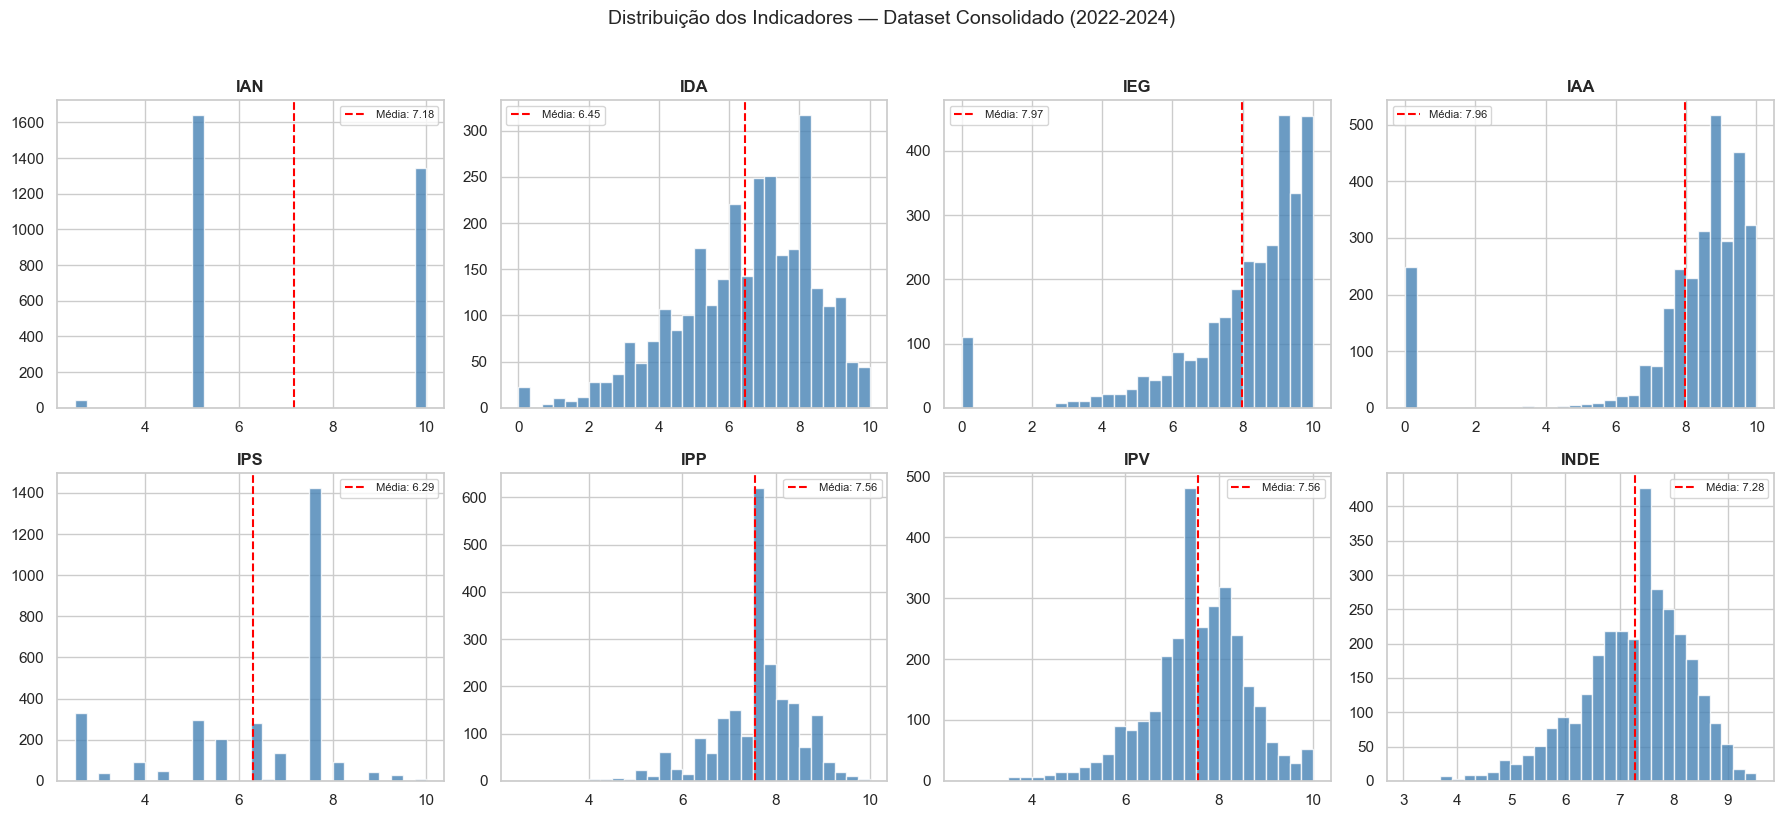

In [240]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(indicadores):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(data.mean(), color='red', linestyle='--',
                    label=f'Média: {data.mean():.2f}')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuição dos Indicadores — Dataset Consolidado (2022-2024)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/01_distribuicao_indicadores.png', dpi=150, bbox_inches='tight')
plt.show()

* O IAN não é um indicador contínuo, é uma nota binária disfarçada (apenas com poucos casos com 2.5). Usar IAN como feature numérica no modelo pode gerar um efeito de step function, não uma relação linear. (Talvez seja interessante no desenvolver do projeto criar uma feature binária `IAN_ADEQUADO`, 1 se IAN > 7.0, 0 caso contrário).

* O pico em IAA ≈ 0 merece uma flag separada: `IAN_SEM_RESPOSTA`. Esses alunos têm perfil sistematicamente diferente e misturá-los com os que realmente se autoavaliaram baixo distorce as médias e a correlação IAAxIDA.

* IPS com apenas 4-5 valores discretos vai criar bins artificiais em qualquer modelo baseado em árvore (interessante enconde como ordinal, não como float).

### Gráfico 02: Evolução dos Indicadores por Ano

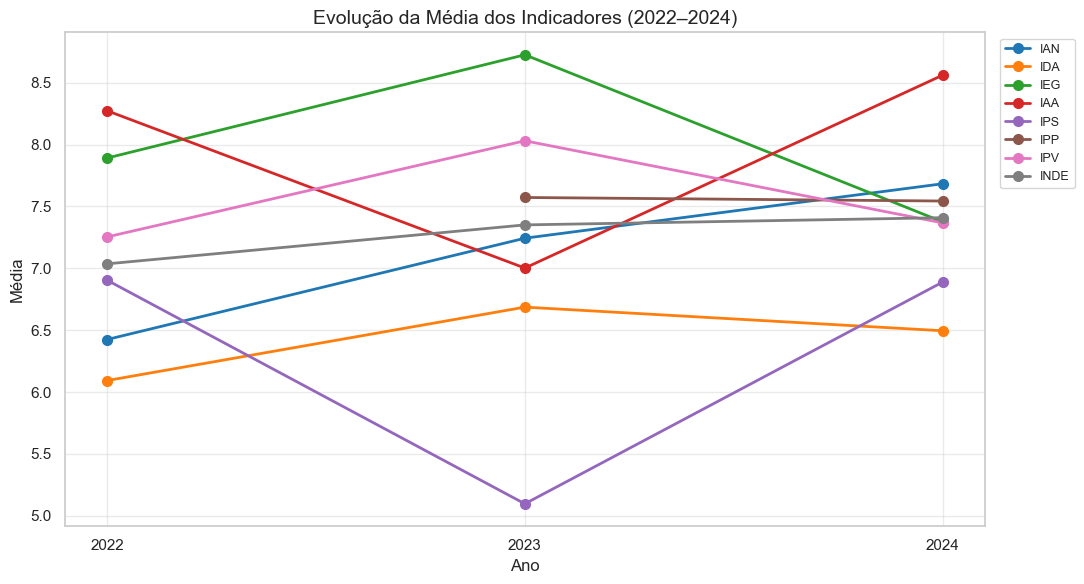

In [ ]:
evolucao = df.groupby('ANO')[indicadores].mean().reset_index()
evolucao_long = evolucao.melt(id_vars='ANO', var_name='Indicador', value_name='Média')

cores = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(11, 6))

for i, ind in enumerate(indicadores):
    dados = evolucao_long[evolucao_long['Indicador'] == ind]
    ax.plot(dados['ANO'], dados['Média'], marker='o', label=ind,
            color=cores[i], linewidth=2, markersize=7)

ax.set_xticks([2022, 2023, 2024])
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Média', fontsize=12)
ax.set_title('Evolução da Média dos Indicadores (2022–2024)', fontsize=14)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../reports/02_evolucao_indicadores.png', dpi=150, bbox_inches='tight')
plt.show()

* A queda do IPS em 2023 (-26%) e a recuperação em 2024 formam um "V" perfeito, isso é estatisticamente suspeito. Interessante verificar se houve mudança metodológica na coleta do IPS entre 2022 e 2023 antes de atribuir a variação a um fenômeno real. Se for real, é um dado muito importante.

* O cruzamento IAA crescente + IDA estagnado é um dos insights mais ricos para o desenvolvimento do projeto: o programa melhora autoestima mas não desempenho, tensão que precisa ser endereçada com proposta concreta de melhoria.

* IPV caindo em 2024 em todos os grupos simultaneamente sugere mudança sistêmica, não individual. 
    * *Hipótese: critério de avaliação do IPV foi revisado em 2024.*

### Gráfico 02b — Distribuição por Pedra e Ano

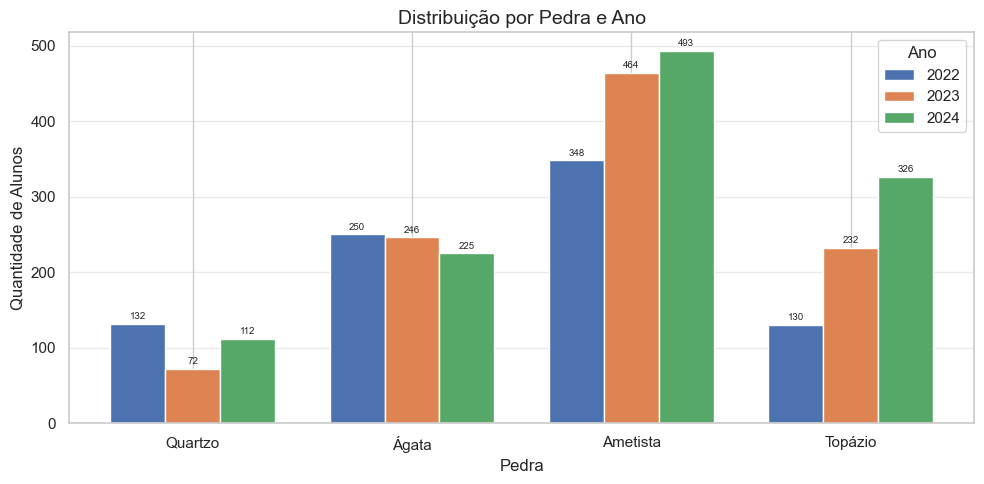

In [243]:
pedra_ano = df.groupby(['ANO', 'PEDRA']).size().reset_index(name='Qtde')

anos = sorted(df['ANO'].unique())
pedras = [p for p in ordem_pedras if p in df['PEDRA'].cat.categories]
x = np.arange(len(pedras))
width = 0.25
cores_anos = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(10, 5))

for i, ano in enumerate(anos):
    dados_ano = pedra_ano[pedra_ano['ANO'] == ano]
    qtdes = [dados_ano[dados_ano['PEDRA'] == p]['Qtde'].values[0]
             if p in dados_ano['PEDRA'].values else 0 for p in pedras]
    bars = ax.bar(x + i * width, qtdes, width, label=str(ano), color=cores_anos[i])
    ax.bar_label(bars, fontsize=7, padding=2)

ax.set_xticks(x + width)
ax.set_xticklabels(pedras)
ax.set_xlabel('Pedra', fontsize=12)
ax.set_ylabel('Quantidade de Alunos', fontsize=12)
ax.set_title('Distribuição por Pedra e Ano', fontsize=14)
ax.legend(title='Ano')
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('../reports/02b_distribuicao_pedras_ano.png', dpi=150, bbox_inches='tight')
plt.show()

* O crescimento de Topázio (+151%) combinado com Ágata estável em absolutos significa que alunos estão "pulando" Ágata, indo de Quartzo/novo direto para Ametista sem passar por Ágata como etapa intermediária. Isso indica que Ágata não é uma fase de progressão natural, mas um grupo de entrada de alunos com perfil específico.

* Para o modelo: PEDRA é uma feature ordinal poderosa, mas sua distribuição desbalançada (Ágata cada vez menor) pode causar problemas de generalização em subgrupos.

### Gráfico 03 — Matriz de Correlação entre os Indicadores

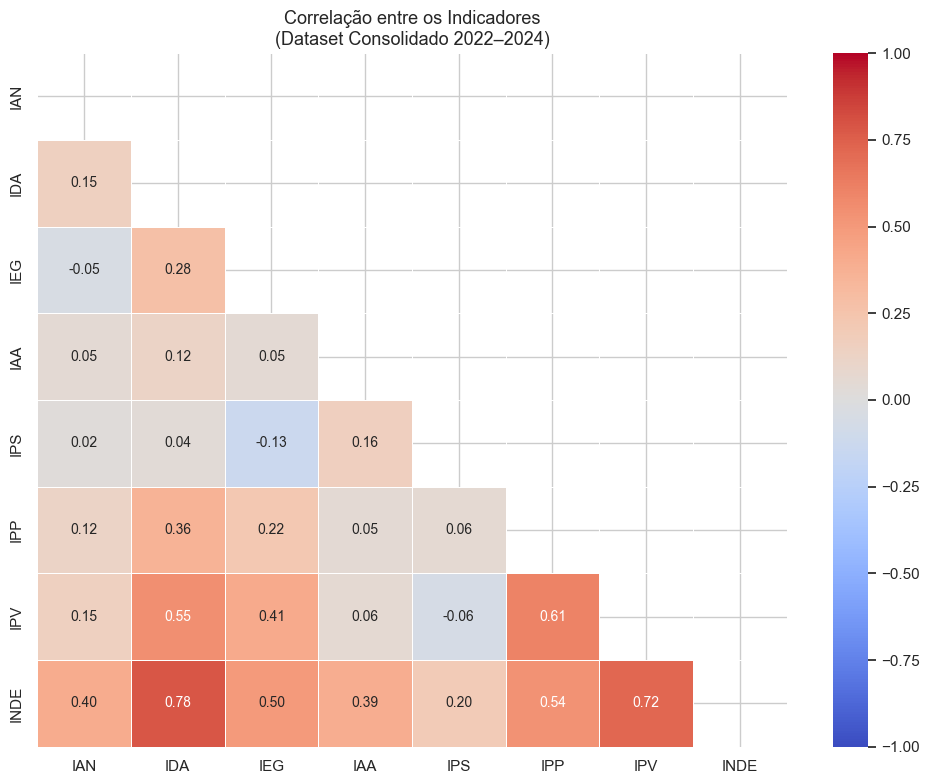

In [244]:
plt.figure(figsize=(10, 8))
corr = df[indicadores].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 10})
plt.title('Correlação entre os Indicadores\n(Dataset Consolidado 2022–2024)', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/03_correlacao.png', dpi=150)
plt.show()

* As três correlações que mais importam para o modelo preditivo, em ordem de prioridade como features:
    * IDAxINDE (0.78): feature mais importante, provavelmente dominará o modelo.
    * IPPxIPV (0.61): par mais colinear fora do INDE, é preciso tomar cuidado com multicolinearidade se usar ambos.
    * IPSxtudo (máx 0.20): feature fraca isolada, mas pode ter efeito de interação com IDA ou IEG que a correlação bivariada não captura.

* IANxIEG (-0.05) é o único par com correlação negativa entre dois indicadores de desempenho, contraintuitivo e potencialmente uma feature de interação útil (`IAN_alto_IEG_baixo`)

### Gráfico 04 — Distribuição do INDE por Pedra

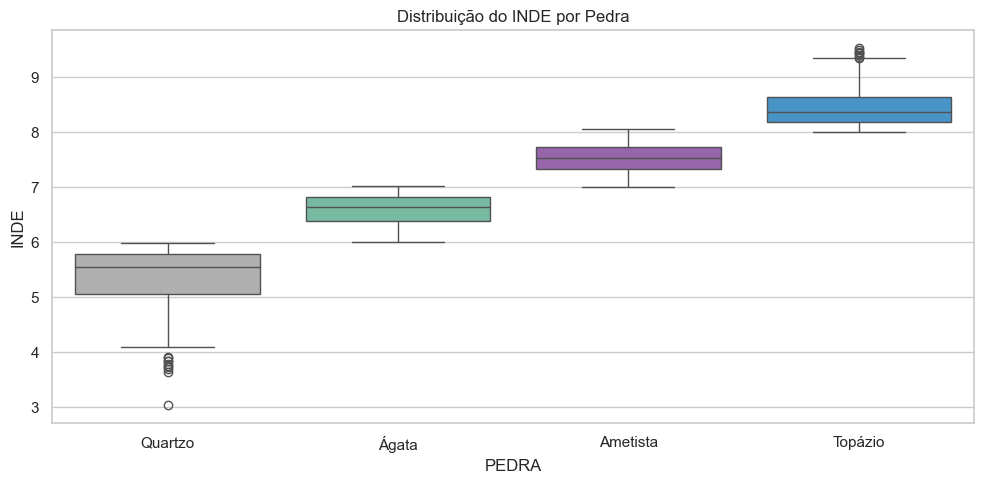

In [245]:
plt.figure(figsize=(10, 5))
ordem = [p for p in ordem_pedras if p in df['PEDRA'].unique()]

sns.boxplot(data=df, x='PEDRA', y='INDE', order=ordem,
            palette=['#B0B0B0', '#6CC5A4', '#9B59B6', '#3498DB'])

plt.title('Distribuição do INDE por Pedra')
plt.tight_layout()
plt.savefig('../reports/04_inde_por_pedra.png', dpi=150)
plt.show()

* A ausência de sobreposição entre caixas confirma que PEDRA pode ser usada como proxy do INDE sem perda de informação relevante, as duas variáveis são quase intercambiáveis. Isso cria risco de *data leakage* no modelo: se usar PEDRA como feature para prever risco (definido com base no INDE), o modelo vai "trapacear". Nota para desenvolvimento: usar apenas uma das duas features ou definir o target de risco sem usar INDE nem PEDRA diretamente.

* Os outliers de Quartzo são poucos mas críticos, são exatamente os casos que o modelo precisa identificar antecipadamente. É importante se certificar de que eles estão no conjunto de treino, mas apenas de teste.

# 4. Salvando Dataset Processado

In [247]:
os.makedirs('../data/processed', exist_ok=True)

# Consolidado
df.to_parquet('../data/processed/pede_consolidado.parquet', index=False)

# Por ano (útil para análises específicas)
df[df['ANO'] == 2022].to_parquet('../data/processed/pede2022_clean.parquet', index=False)
df[df['ANO'] == 2023].to_parquet('../data/processed/pede2023_clean.parquet', index=False)
df[df['ANO'] == 2024].to_parquet('../data/processed/pede2024_clean.parquet', index=False)

print(f"Total: {len(df)} registros | {df['ANO'].nunique()} anos")
print(f"\nArquivos gerados:")
print("  ../data/processed/pede_consolidado.parquet")
print("  ../data/processed/pede2022_clean.parquet")
print("  ../data/processed/pede2023_clean.parquet")
print("  ../data/processed/pede2024_clean.parquet")

Total: 3030 registros | 3 anos

Arquivos gerados:
  ../data/processed/pede_consolidado.parquet
  ../data/processed/pede2022_clean.parquet
  ../data/processed/pede2023_clean.parquet
  ../data/processed/pede2024_clean.parquet
